# Capstone Project: Exploratory Data Analysis
## Understanding Six-Month Voluntary Employee Attrition

This project explores whether workforce information available at a monthly snapshot contains useful patterns associated with voluntary attrition during the following six months. Because the outcome has two possible values, attrition or retention, this is a **classification problem**.

The analysis moves from data quality and outcome definition to numeric, categorical, and time-based workforce patterns that may support prediction. Each row represents one employee in one month, so the same employee can appear across snapshots. The findings describe relationships in the data; they do not establish that a workforce characteristic caused attrition.


In [1]:
import warnings

# Load only the libraries needed for data review and visualization.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)

# Use the same KP colors.
kp_palette_dict = {
    "blue": "#006BA6",
    "green": "#78BE20",
    "red": "#CB333B",
    "orange": "#FF6A00",
    "gray_dark": "#5A5A5A",
    "blue_gray": "#8E9FBC",
    "warm_gray": "#AEA9A0",
    "sage_green": "#A3AA83",
    "light_brown": "#BF9474",
    "olive_gold": "#A89968",
    "teal": "#7EA9AF",
}

kp_risk_cmap = LinearSegmentedColormap.from_list(
    "kp_risk",
    ["white", kp_palette_dict["olive_gold"], kp_palette_dict["orange"], kp_palette_dict["red"]],
)


def apply_plotly_layout(fig, title, height, left_margin=180):
    # Apply a consistent KP presentation style to interactive charts.
    fig.update_layout(
        template="plotly_white",
        title={"text": title, "x": 0.02, "xanchor": "left"},
        height=height,
        font={"color": kp_palette_dict["gray_dark"]},
        paper_bgcolor="white",
        plot_bgcolor="white",
        hoverlabel={"bgcolor": "white"},
        margin={"l": left_margin, "r": 55, "t": 85, "b": 65},
        showlegend=False,
    )
    return fig


def show_plotly_figure(fig):
    # Keep the chart interactive and remove the Plotly logo.
    fig.show(config={"displaylogo": False, "responsive": True})

TARGET_COL = "attrition_6mo_voluntary"
OUTCOME_WINDOW_MONTHS = 6


## 1. Data and Initial Quality Review

I begin by checking the dataset's size, field types, missing values, ranges, unique category counts, and category concentration. These checks establish what the source represents and identify fields that require additional care before modeling.

Key fields have the following business meaning: `snapshot_date` is the month-end workforce view; `attrition_6mo_voluntary` indicates a qualifying voluntary exit during the next six months; `tenure_months` measures service through the snapshot; and `annual_salary` is annualized base pay at scheduled hours. `compa_ratio` compares pay standardized to a 40-hour schedule with the median pay for the same grade and month. A ratio of 1.0 means the employee is at that peer median, not at a formal salary-range midpoint. Performance and manager fields describe prior ratings, team size, team tenure, performance mix, and prior team turnover. Region, entity, service area, job family, job code, and department are workforce groupings.


In [2]:
# Load the monthly workforce snapshots.
from sqlalchemy import create_engine

# Windows authentication avoids storing credentials in the notebook.
engine = create_engine(
    "mssql+pyodbc://@csc2cwp21115517.cloud.kp.org,2410/Talent" #Production
    # "mssql+pyodbc://@csc2cwn21113630.CLOUD.KP.ORG,2401/Talent"  #Development
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

sql = """
       EXEC Attrition.Employee_Comp_Monthly
       @snapshot_months_back = 36,
       @mask_nuid = 1,
       @regions = 'Northern California,Executives';        
      """

df = pd.read_sql(sql, engine)

print("Rows loaded:", f"{len(df):,}")
print("Columns loaded:", df.shape[1])
print("Snapshots loaded:", df["snapshot_date"].nunique())


Rows loaded: 3,272,078
Columns loaded: 30
Snapshots loaded: 36


In [3]:
# Review field types and missing values before choosing preparation steps.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3272078 entries, 0 to 3272077
Data columns (total 30 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   snapshot_date            object 
 1   nuid                     object 
 2   manager_nuid             object 
 3   region                   object 
 4   entity                   object 
 5   service_area_new         object 
 6   medical_center           object 
 7   hire_date                object 
 8   termination_date         object 
 9   job_code_id              object 
 10  job_code_description     object 
 11  job_family               object 
 12  department_code          object 
 13  department_name          object 
 14  loc_phy_code             object 
 15  physical_location        object 
 16  grade                    object 
 17  annual_salary            float64
 18  market_mid               float64
 19  compa_ratio_delta_12mo   float64
 20  performance_rating       float64
 21  attritio

In [4]:
# Inspect every source column, then display the model-relevant fields.
column_review = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_percent": df.isna().mean() * 100,
    "unique_values": df.nunique(dropna=True),
}).reset_index(names="column")

review_columns = [
    "snapshot_date",
    "region",
    "entity",
    "service_area_new",
    "job_code_id",
    "department_code",
    "job_family",
    "annual_salary",
    "compa_ratio_delta_12mo",
    "performance_rating",
    TARGET_COL,
    "tenure_months",
    "compa_ratio",
    "low_performer",
    "mgr_team_size",
    "mgr_avg_team_tenure",
    "mgr_low_perf_pct",
    "mgr_attrition_6mo_rate",
    "mgr_attrition_12mo_rate",
]
display(
    column_review.loc[column_review["column"].isin(review_columns)]
    .round({"missing_percent": 1})
    .reset_index(drop=True)
)

# Summarize ranges only for continuous candidate features.
numeric_review_columns = [
    "annual_salary",
    "compa_ratio_delta_12mo",
    "performance_rating",
    "tenure_months",
    "compa_ratio",
    "mgr_team_size",
    "mgr_avg_team_tenure",
    "mgr_low_perf_pct",
    "mgr_attrition_6mo_rate",
    "mgr_attrition_12mo_rate",
]
numeric_review = df[numeric_review_columns].agg(["min", "median", "max"]).transpose()
display(numeric_review.round(3))

# Review broad and detailed categorical fields as potential workforce context.
categorical_review_features = [
    "region",
    "entity",
    "service_area_new",
    "job_family",
    "job_code_id",
    "department_code",
]
category_review = pd.DataFrame({
    "feature": categorical_review_features,
    "unique_values": df[categorical_review_features].nunique(dropna=True).values,
    "missing_percent": df[categorical_review_features].isna().mean().values,
    "largest_group": [
        df[feature].value_counts(dropna=True).index[0]
        for feature in categorical_review_features
    ],
    "largest_group_share": [
        df[feature].value_counts(normalize=True, dropna=True).max()
        for feature in categorical_review_features
    ],
})
display(
    category_review.style.format({
        "missing_percent": "{:.1%}",
        "largest_group_share": "{:.1%}",
    })
)


,column,data_type,missing_percent,unique_values
0,snapshot_date,object,0.0,36
1,region,object,0.0,2
2,entity,object,0.0,7
3,service_area_new,object,0.0,17
4,job_code_id,object,0.0,3074
5,job_family,object,0.0,63
6,department_code,object,0.0,1139
7,annual_salary,float64,1.0,65566
8,compa_ratio_delta_12mo,float64,8.8,423041
9,performance_rating,float64,24.5,5


,min,median,max
annual_salary,1013.424,94660.384,2450000.059
compa_ratio_delta_12mo,-7.770,0.000,7.770
performance_rating,1.000,3.000,5.000
tenure_months,0.000,105.000,731.000
compa_ratio,0.337,1.000,8.827
mgr_team_size,1.000,23.000,328.000
mgr_avg_team_tenure,0.000,131.000,540.000
mgr_low_perf_pct,0.000,0.000,1.000
mgr_attrition_6mo_rate,0.000,0.000,1.000
mgr_attrition_12mo_rate,0.000,0.000,1.000


,feature,unique_values,missing_percent,largest_group,largest_group_share
0,region,2,0.0%,Northern California,99.5%
1,entity,7,0.0%,06,51.7%
2,service_area_new,17,0.0%,"Regional - California, North",10.3%
3,job_family,63,0.0%,Nursing (Licensed),30.9%
4,job_code_id,3074,0.0%,022882,13.3%
5,department_code,1139,0.0%,1280,3.8%


The source contains approximately 3.3 million employee-month records across 36 monthly snapshots and 30 fields. Annual salary and current pay position each have about 1% missing values, while performance rating is unavailable for about one-quarter of records. The target is unavailable for about one-fifth of the source because the newest snapshots do not yet have a complete six-month outcome window.

The categorical fields are complete but vary greatly in detail: job family has about 60 categories, department code about 1,100, and job code about 3,100. Region is highly concentrated, with approximately 99.5% of records in one group. This concentration and the detailed job and department categories may limit how well these fields generalize to later periods.

The maximum annualized salary is about $2.45 million, the highest pay ratio is below 9, and some manager teams exceed 300 employees. I keep these unusual values visible in EDA; I will check their source and influence before deciding whether any modeling safeguard is needed.


## 2. Outcome and Class Balance

**Data leakage** occurs when an analysis uses information that would not have been known at the snapshot date. To prevent this, termination details and employee and manager identifiers are excluded from candidate predictors. The stored procedure assigns the target only when its durable termination archive contains the complete six-month outcome window. This notebook verifies that each retained snapshot is fully labeled instead of estimating maturity from the newest snapshot date.

Source date range: 2023-09-30 to 2026-08-31
Latest snapshot with a complete target: 2026-01-31
Rows retained with mature outcomes: 2,637,508
Recent unlabeled rows excluded: 634,570
Missing targets among retained rows: 0


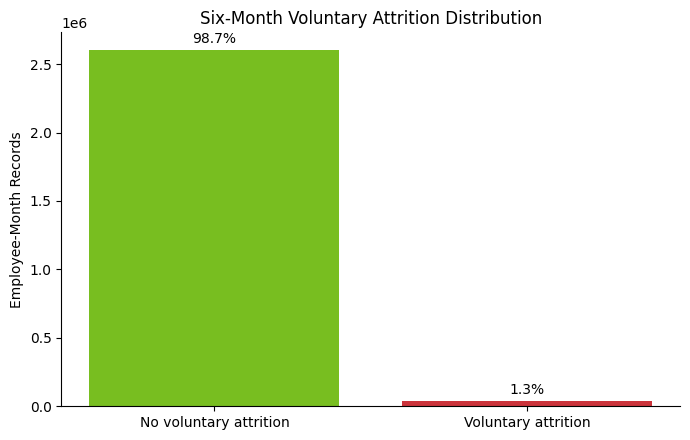

Mature attrition cases: 35,308
Observed mature attrition rate: 1.34%


In [5]:
df = df.copy()
df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])

latest_available_snapshot = df["snapshot_date"].max()

# Remove identifiers and the future termination field before exploring predictors.
leakage_cols = ["nuid", "manager_nuid", "termination_date"]
df_model_all = df.drop(columns=leakage_cols, errors="ignore").copy()

# Confirm that each snapshot is either fully labeled or fully unavailable.
snapshot_target_status = (
    df_model_all.groupby("snapshot_date")[TARGET_COL]
    .agg(records="size", labeled_records="count")
    .reset_index()
)
snapshot_target_status["missing_targets"] = (
    snapshot_target_status["records"]
    - snapshot_target_status["labeled_records"]
)

partial_snapshots = snapshot_target_status.loc[
    snapshot_target_status["labeled_records"].between(
        1, snapshot_target_status["records"] - 1
    )
]
if not partial_snapshots.empty:
    raise ValueError("At least one snapshot contains only partial target coverage.")

fully_labeled_snapshots = snapshot_target_status.loc[
    snapshot_target_status["missing_targets"].eq(0), "snapshot_date"
]
if fully_labeled_snapshots.empty:
    raise ValueError("No snapshot has a complete six-month target window.")

label_maturity_cutoff = fully_labeled_snapshots.max()
earlier_snapshot_status = snapshot_target_status.loc[
    snapshot_target_status["snapshot_date"] <= label_maturity_cutoff
]
if earlier_snapshot_status["missing_targets"].gt(0).any():
    raise ValueError("Complete target snapshots are not contiguous over time.")

# Retain only snapshots with complete archived outcomes.
df_model = df_model_all.loc[
    df_model_all["snapshot_date"] <= label_maturity_cutoff
].copy()

dropped_unlabeled_rows = len(df_model_all) - len(df_model)
missing_mature_targets = int(df_model[TARGET_COL].isna().sum())

print("Source date range:", df["snapshot_date"].min().date(), "to", latest_available_snapshot.date())
print("Latest snapshot with a complete target:", label_maturity_cutoff.date())
print("Rows retained with mature outcomes:", f"{len(df_model):,}")
print("Recent unlabeled rows excluded:", f"{dropped_unlabeled_rows:,}")
print("Missing targets among retained rows:", f"{missing_mature_targets:,}")

if df_model.empty or missing_mature_targets > 0:
    raise ValueError("The mature EDA dataset does not have complete target values.")

# Confirm that each mature row is one employee-month and the target is binary.
mature_employee_keys = df.loc[df_model.index, ["snapshot_date", "nuid"]]
duplicate_employee_months = int(
    mature_employee_keys.duplicated(["snapshot_date", "nuid"]).sum()
)
if duplicate_employee_months > 0:
    raise ValueError(
        f"Found {duplicate_employee_months:,} duplicate employee-month records."
    )

observed_target_values = set(df_model[TARGET_COL].dropna().unique())
if observed_target_values != {0.0, 1.0}:
    raise ValueError(
        f"{TARGET_COL} must contain only 0 and 1; found {observed_target_values}."
    )

positive_employee_months = int(df_model[TARGET_COL].eq(1).sum())
if positive_employee_months != int(df_model[TARGET_COL].sum()):
    raise ValueError("The binary-target sum does not match the positive-row count.")

# A positive row is an employee-month label, not necessarily a unique exit.
target_counts = df_model[TARGET_COL].value_counts().sort_index()
target_rates = target_counts / target_counts.sum()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(
    ["No voluntary attrition", "Voluntary attrition"],
    target_counts.values,
    color=[kp_palette_dict["green"], kp_palette_dict["red"]],
)
ax.bar_label(
    bars,
    labels=[f"{target_rates.loc[0]:.1%}", f"{target_rates.loc[1]:.1%}"],
    padding=3,
)
ax.set_title("Six-Month Voluntary Attrition Distribution")
ax.set_ylabel("Employee-Month Records")
ax.set_xlabel("")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print("Mature attrition cases:", f"{int(target_counts.loc[1]):,}")
print("Observed mature attrition rate:", f"{target_rates.loc[1]:.2%}")

After requiring a complete six-month outcome window, approximately 2.6 million employee-month records remain and about 0.6 million recent records are excluded. The mature population contains about 35,000 positive employee-month records, an observed rate near **1.3%**, with no missing target values. The latest fully labeled snapshot is January 2026.

The checks confirm that the target contains only `0` and `1`, that each retained employee appears once per snapshot, and that summing the target matches the direct count of positive rows. Because one employee can appear in several monthly snapshots, these are positive employee-month labels, not unique employees or termination events.

Because attrition is uncommon, a model could appear accurate by predicting retention for almost everyone. The modeling stage therefore needs measures that show whether positive records are ranked and identified effectively, including average precision, recall, precision, lift, and the size of the HR review list.


## 3. Candidate Features and Missing Values

The candidate features describe information known at the monthly snapshot, including pay position, tenure, performance, manager context, and organizational or occupational groups. Missing values remain unchanged during EDA so their extent is visible; any replacement values will be learned later from training data only.


Snapshot-time feature engineering completed.


,missing_percent
medical_center,0.0
grade,1.1
market_mid,1.1
annual_salary,1.2
compa_ratio,1.2
compa_tenure_interaction,1.2
mgr_low_perf_pct,2.4
mgr_attrition_6mo_rate,7.1
compa_ratio_delta_12mo,9.5
mgr_attrition_12mo_rate,13.6


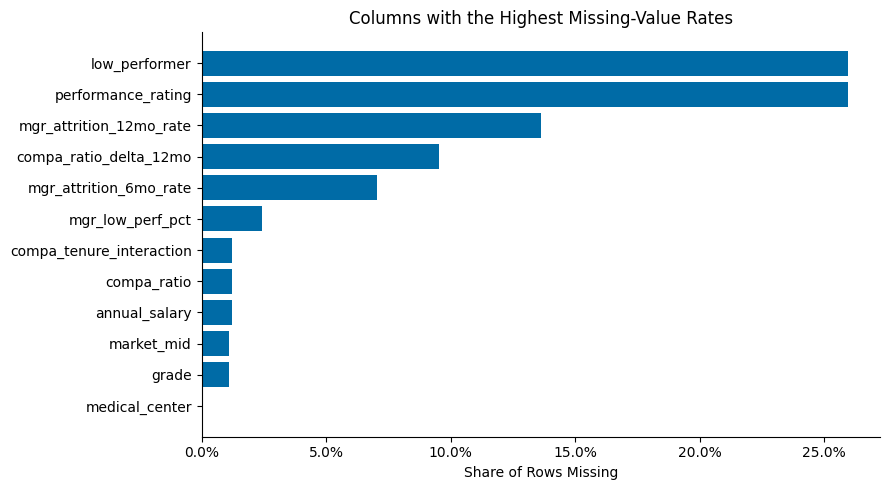

In [6]:
# Create the same snapshot-time features used in the modeling.
df_model["underpaid_flag"] = (df_model["compa_ratio"] < 1).astype(int)
df_model["high_mgr_attrition"] = (
    df_model["mgr_attrition_12mo_rate"].fillna(0) > 0
).astype(int)
df_model["compa_tenure_interaction"] = (
    df_model["compa_ratio"] * df_model["tenure_months"]
)

df_model = df_model.replace([np.inf, -np.inf], np.nan)
print("Snapshot-time feature engineering completed.")


# Report missing data as observed; do not fill values for EDA charts.
missing_summary = (
    df_model.isna().mean()
    .sort_values(ascending=False)
    .loc[lambda values: values > 0]
    .head(12)
    .sort_values()
)

missing_display = (missing_summary * 100).rename("missing_percent").to_frame().round(1)
display(missing_display)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    missing_summary.index,
    missing_summary.values,
    color=kp_palette_dict["blue"],
)
ax.set_title("Columns with the Highest Missing-Value Rates")
ax.set_xlabel("Share of Rows Missing")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


Performance rating and low-performer status have the most missing values in the mature population, at approximately 26% each. The manager-team attrition measures have about 7% and 14% missing values, while current salary and pay position are missing for only about 1% of records. The 12-month pay-change field is missing for approximately 10%.

A missing performance value may reflect eligibility or a business process rather than employee performance. Current `compa_ratio`, which represents pay position, is more complete than the 12-month pay-change field and is the clearer measure for exploratory comparisons. Missing values will be handled consistently inside the later modeling pipeline.


### Outliers and cleaning decisions

I removed recent rows without a complete target window and checked for duplicate employee-month records; the duplicate check found none. I leave missing predictor values visible in EDA and learn replacements from training data only in the baseline below.

The range table above identifies unusual observations: the maximum annualized salary is about $2.45 million versus a median near $95,000, and the maximum tenure exceeds 60 years versus a median under nine years. These could be legitimate records, so I do not automatically discard them. I leave salary out of this simple baseline while its extreme values receive further review; the separate modeling work can test whether it improves later-period performance.

## 4. Categorical Workforce Context

The broad organizational fields describe where employees work, while job family, job code, and department add occupation and local-workforce context. `job_code_id` and `department_code` are categorical labels, not numeric measures.

The following views display category names because they are appropriate for this analysis. To reduce unstable comparisons, each chart includes only job families or departments represented by at least 1,000 mature employee-month records. The charts focus on the 15 highest observed rates so the labels remain readable; they are descriptive rankings, not evidence that a category causes attrition or should automatically enter the model.


,job_family,records,attrition_cases,attrition_rate
42,Research,"1,477",83,5.62%
43,Research & Development,"8,669",397,4.58%
2,Ancillary Diagnostic Services,"2,233",56,2.51%
4,Behavioral Health Care Svcs,"114,459","2,790",2.44%
41,Rehabilitative/Alternative Med,"91,373","2,207",2.42%
12,Education & Training,"8,788",202,2.30%
13,Education/Training,"9,305",177,1.90%
32,Nutrition/Food Services,"26,565",480,1.81%
5,Behavioral Health Services,"2,004",35,1.75%
38,QA/UR/Case Management,"2,549",43,1.69%


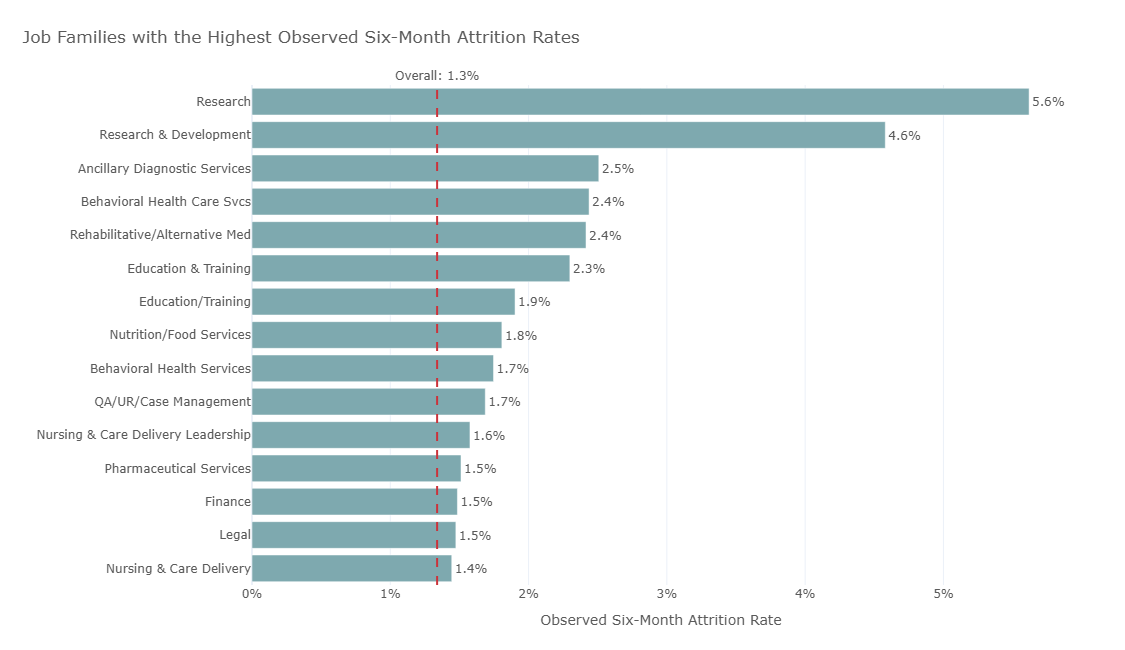

,department_label,records,attrition_cases,attrition_rate
175,2255 - Primary Care-Flu Immuno,"7,144",917,12.84%
331,9766 - T&E -PsychologySpecialPrgms,"4,326",298,6.89%
140,1821 - Occupational Therapy-Inpatient,"2,108",139,6.59%
154,2014 - Pediatrics-Rehab Services,"4,635",242,5.22%
194,2411 - Speech Therapy-Inpatient,"2,224",99,4.45%
333,9884 - RI Medical Records_Recharge,"10,243",450,4.39%
332,9857 - Rsrch-Invstgtr Staffg Mdl Dept,"3,800",163,4.29%
44,0701 - Cardiac Catheterization-Other,"2,307",89,3.86%
215,4002 - O/P Pharmacy 3rd Floor - A,"1,802",67,3.72%
327,9703 - GME - Pediatric Residency,"1,053",39,3.70%


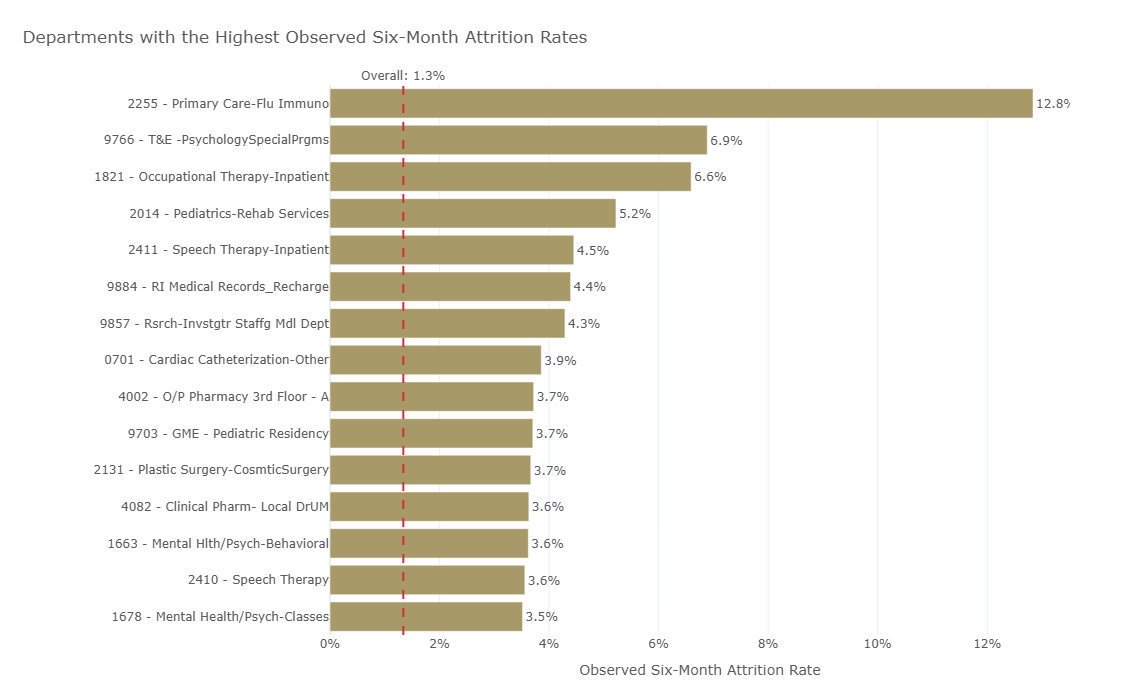

In [7]:
# Require enough records before comparing a category's observed attrition rate.
MIN_CATEGORY_RECORDS = 1_000
TOP_CATEGORIES = 15
overall_attrition_rate = df_model[TARGET_COL].mean()

# Summarize named job families in the mature EDA population.
# attrition_cases sums the binary target, so it counts positive employee-month records.
job_family_summary = (
    df_model.dropna(subset=["job_family"])
    .groupby("job_family")
    .agg(
        records=(TARGET_COL, "size"),
        attrition_cases=(TARGET_COL, "sum"),
        attrition_rate=(TARGET_COL, "mean"),
    )
    .query("records >= @MIN_CATEGORY_RECORDS")
    .reset_index()
    .sort_values("attrition_rate", ascending=False)
)
top_job_families = job_family_summary.head(TOP_CATEGORIES).sort_values("attrition_rate")

display(
    job_family_summary.head(TOP_CATEGORIES).style.format({
        "records": "{:,}",
        "attrition_cases": "{:,.0f}",
        "attrition_rate": "{:.2%}",
    })
)

fig = go.Figure(
    go.Bar(
        x=top_job_families["attrition_rate"],
        y=top_job_families["job_family"],
        orientation="h",
        marker_color=kp_palette_dict["teal"],
        text=top_job_families["attrition_rate"],
        texttemplate="%{text:.1%}",
        textposition="outside",
        customdata=top_job_families[["records", "attrition_cases"]],
        hovertemplate=(
            "%{y}<br>Observed attrition rate: %{x:.2%}"
            "<br>Employee-month records: %{customdata[0]:,}"
            "<br>Attrition cases: %{customdata[1]:,.0f}<extra></extra>"
        ),
    )
)
fig.add_vline(
    x=overall_attrition_rate,
    line_color=kp_palette_dict["red"],
    line_dash="dash",
    annotation_text=f"Overall: {overall_attrition_rate:.1%}",
    annotation_position="top",
)
apply_plotly_layout(
    fig,
    "Job Families with the Highest Observed Six-Month Attrition Rates",
    height=650,
    left_margin=230,
)
fig.update_xaxes(title_text="Observed Six-Month Attrition Rate", tickformat=".0%")
fig.update_yaxes(title_text="", automargin=True)
show_plotly_figure(fig)

# Combine department code and name so each displayed label remains identifiable.
department_source = df_model.dropna(
    subset=["department_code", "department_name"]
).copy()
department_source["department_label"] = (
    department_source["department_code"].astype("string")
    + " - "
    + department_source["department_name"].astype("string")
)
department_summary = (
    department_source.groupby("department_label")
    .agg(
        records=(TARGET_COL, "size"),
        attrition_cases=(TARGET_COL, "sum"),
        attrition_rate=(TARGET_COL, "mean"),
    )
    .query("records >= @MIN_CATEGORY_RECORDS")
    .reset_index()
    .sort_values("attrition_rate", ascending=False)
)
top_departments = department_summary.head(TOP_CATEGORIES).sort_values("attrition_rate")

display(
    department_summary.head(TOP_CATEGORIES).style.format({
        "records": "{:,}",
        "attrition_cases": "{:,.0f}",
        "attrition_rate": "{:.2%}",
    })
)

fig = go.Figure(
    go.Bar(
        x=top_departments["attrition_rate"],
        y=top_departments["department_label"],
        orientation="h",
        marker_color=kp_palette_dict["olive_gold"],
        text=top_departments["attrition_rate"],
        texttemplate="%{text:.1%}",
        textposition="outside",
        customdata=top_departments[["records", "attrition_cases"]],
        hovertemplate=(
            "%{y}<br>Observed attrition rate: %{x:.2%}"
            "<br>Employee-month records: %{customdata[0]:,}"
            "<br>Attrition cases: %{customdata[1]:,.0f}<extra></extra>"
        ),
    )
)
fig.add_vline(
    x=overall_attrition_rate,
    line_color=kp_palette_dict["red"],
    line_dash="dash",
    annotation_text=f"Overall: {overall_attrition_rate:.1%}",
    annotation_position="top",
)
apply_plotly_layout(
    fig,
    "Departments with the Highest Observed Six-Month Attrition Rates",
    height=700,
    left_margin=330,
)
fig.update_xaxes(title_text="Observed Six-Month Attrition Rate", tickformat=".0%")
fig.update_yaxes(title_text="", automargin=True)
show_plotly_figure(fig)


Research has the highest qualifying job-family rate at about 5.6%, followed by Research & Development near 4.6%; Ancillary Diagnostic Services is near 2.5%. The overall mature-population rate is about 1.3%. I would check whether similarly named research and behavioral-health categories represent distinct workforces before interpreting their rankings.

Primary Care-Flu Immunization has the highest department rate at about 13%. A psychology special-program department and Occupational Therapy-Inpatient are both near 7%. These groups each meet the 1,000-record threshold, but their rates may reflect specialized or time-limited work and should not be treated as individual risk estimates.

For HR, these results identify areas where staffing context deserves a closer look. For modeling, each rate counts positive employee-month labels rather than unique exits; job family and department still need calendar-based validation before either is retained as a predictor. The charts show association, not a cause of attrition.


## 5. Key Numeric Relationships

The numeric review compares each candidate feature with the attrition outcome and then examines typical tenure and pay position for each outcome. Correlation describes the direction and strength of a linear relationship; it does not establish cause or account for other workforce characteristics.


In [8]:
# Rank candidate numeric features by their linear relationship with attrition.
correlation_features = [
    "annual_salary",
    "compa_ratio",
    "performance_rating",
    "tenure_months",
    "low_performer",
    "mgr_team_size",
    "mgr_avg_team_tenure",
    "mgr_low_perf_pct",
    "mgr_attrition_6mo_rate",
    "mgr_attrition_12mo_rate",
    "underpaid_flag",
    "high_mgr_attrition",
    "compa_tenure_interaction",
    TARGET_COL,
]
correlations = df_model[correlation_features].corr()
target_correlations = (
    correlations[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=abs, ascending=False)
    .rename("correlation_with_attrition")
    .to_frame()
)

print("Largest absolute correlations with attrition:")
display(target_correlations.head(6).round(3))


Largest absolute correlations with attrition:


,correlation_with_attrition
tenure_months,-0.072
compa_tenure_interaction,-0.069
annual_salary,-0.061
compa_ratio,-0.047
mgr_avg_team_tenure,-0.046
mgr_attrition_12mo_rate,0.039


Tenure has the strongest individual linear relationship with attrition at about -0.07. Pay position multiplied by tenure is similar, partly because it contains tenure by construction; annual salary is near -0.06. Prior manager-team attrition has a small positive relationship near 0.04.

These correlations are modest. I take them as reasons to test tenure, compensation, and manager context together, not as evidence that any one feature can distinguish attrition from retention or independently improve the model.


In [9]:
# Compare typical tenure and pay position for attrition and retention records.
median_by_outcome = (
    df_model.groupby(TARGET_COL)[["tenure_months", "compa_ratio"]]
    .median()
    .rename(index={0.0: "Retention", 1.0: "Voluntary attrition"})
)
display(median_by_outcome.round(3))


,tenure_months,compa_ratio
attrition_6mo_voluntary,,
Retention,104.0,1.000
Voluntary attrition,36.0,0.976


Employee-month records followed by voluntary attrition have a median tenure of about three years, compared with nearly nine years for retention. Their median pay position is slightly lower, at about 0.98 of the grade-month peer median versus 1.00 for retention.

The tenure difference is clearer than the pay-position difference. I will examine the two together, while recognizing that job and department mix may account for part of either pattern. Neither comparison shows why an employee left.


## 6. Patterns That Inform Modeling

The final views add time, tenure-pay interactions, performance, and manager context. Together with the categorical review, they show why a useful model will need calendar-based evaluation and a combination of employee, occupational, and workplace features rather than one simple rule.


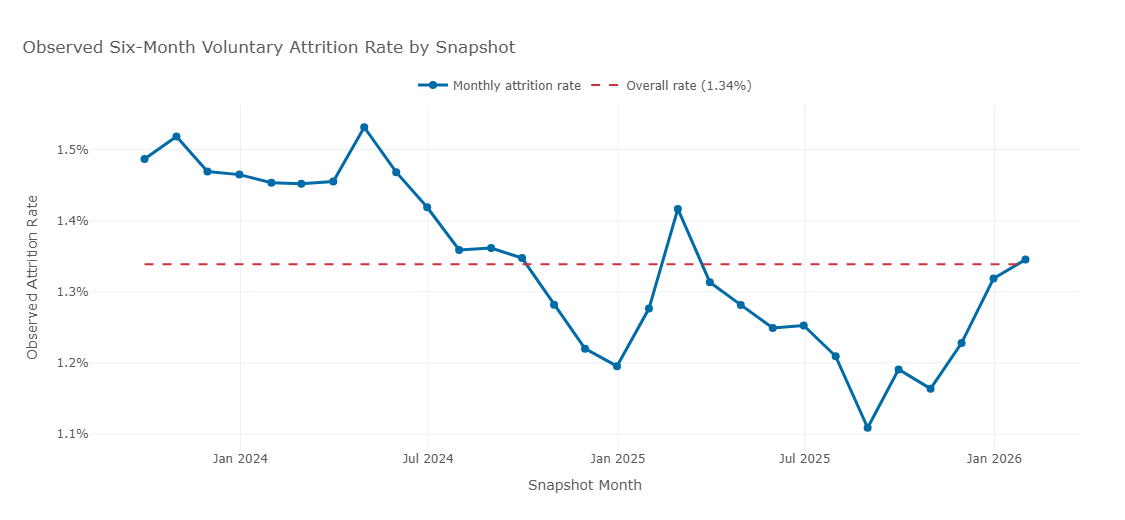

Lowest monthly rate: 1.11%
Highest monthly rate: 1.53%


In [10]:
# Calculate the six-month attrition rate and headcount for each mature snapshot.
# attrition_cases sums the binary target, so it counts positive employee-month records.
attrition_by_month = (
    df_model.groupby("snapshot_date")
    .agg(
        headcount=(TARGET_COL, "size"),
        attrition_cases=(TARGET_COL, "sum"),
        attrition_rate=(TARGET_COL, "mean"),
    )
    .reset_index()
    .sort_values("snapshot_date")
)
overall_attrition_rate = df_model[TARGET_COL].mean()

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=attrition_by_month["snapshot_date"],
        y=attrition_by_month["attrition_rate"],
        mode="lines+markers",
        name="Monthly attrition rate",
        line={"color": kp_palette_dict["blue"], "width": 3},
        marker={"color": kp_palette_dict["blue"], "size": 8},
        customdata=attrition_by_month[["headcount", "attrition_cases"]],
        hovertemplate=(
            "Monthly rate: %{y:.2%}"
            "<br>Snapshot headcount: %{customdata[0]:,}"
            "<br>Attrition cases: %{customdata[1]:,.0f}<extra></extra>"
        ),
    )
)
fig.add_trace(
    go.Scatter(
        x=attrition_by_month["snapshot_date"],
        y=np.repeat(overall_attrition_rate, len(attrition_by_month)),
        mode="lines",
        name=f"Overall rate ({overall_attrition_rate:.2%})",
        line={"color": kp_palette_dict["red"], "width": 2, "dash": "dash"},
        hovertemplate="Overall rate: %{y:.2%}<extra></extra>",
    )
)

apply_plotly_layout(
    fig,
    "Observed Six-Month Voluntary Attrition Rate by Snapshot",
    height=520,
    left_margin=90,
)
fig.update_xaxes(title_text="Snapshot Month")
fig.update_yaxes(title_text="Observed Attrition Rate", tickformat=".1%")
fig.update_layout(
    showlegend=True,
    hovermode="x unified",
    legend={
        "orientation": "h",
        "y": 1.10,
        "x": 0.5,
        "xanchor": "center",
        "title_text": "",
    },
    margin={"l": 90, "r": 45, "t": 105, "b": 70},
)
show_plotly_figure(fig)

print("Lowest monthly rate:", f"{attrition_by_month['attrition_rate'].min():.2%}")
print("Highest monthly rate:", f"{attrition_by_month['attrition_rate'].max():.2%}")


The observed six-month attrition rate ranges from about **1.1% to 1.5%** across mature monthly snapshots. It is generally higher in the earliest periods, reaches a low in late 2025, and rises again by the last fully labeled snapshot in January 2026. The near-zero rates seen in the earlier source extract are no longer present.

The revised source retains voluntary-exit records whose original action can be overwritten by later HR transactions. Complete labels through January 2026 support this EDA, while later snapshots remain unavailable for outcome comparisons until their six-month windows mature.

**Modeling implication:** I will train on earlier snapshots and validate on later mature ones to see whether performance carries forward as the workforce and observed rate change.


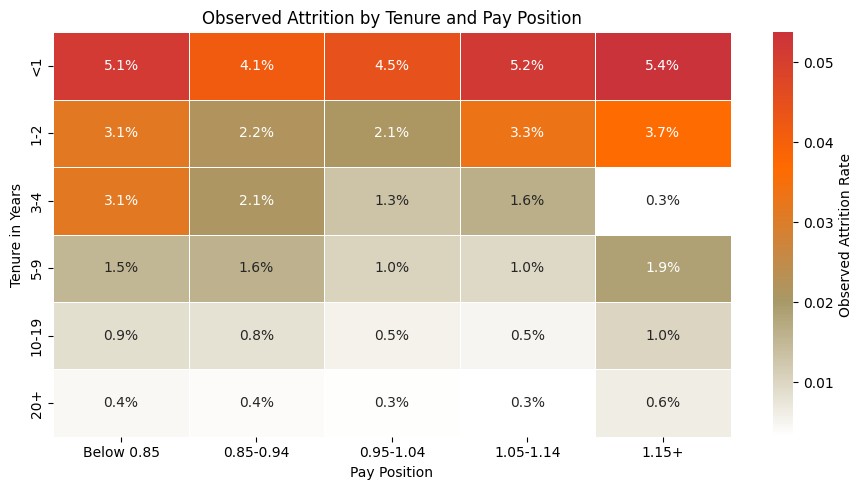

In [11]:
# Compare tenure and pay together because their relationship may not be additive.
tenure_labels = ["<1", "1-2", "3-4", "5-9", "10-19", "20+"]
pay_labels = ["Below 0.85", "0.85-0.94", "0.95-1.04", "1.05-1.14", "1.15+"]

df_model["tenure_group"] = pd.cut(
    df_model["tenure_months"] / 12,
    bins=[0, 1, 3, 5, 10, 20, np.inf],
    labels=tenure_labels,
    right=False,
    include_lowest=True,
)
df_model["pay_position_group"] = pd.cut(
    df_model["compa_ratio"],
    bins=[-np.inf, 0.85, 0.95, 1.05, 1.15, np.inf],
    labels=pay_labels,
    right=False,
)

tenure_pay_summary = (
    df_model.dropna(subset=["tenure_group", "pay_position_group"])
    .groupby(["tenure_group", "pay_position_group"], observed=False)
    .agg(records=(TARGET_COL, "size"), attrition_rate=(TARGET_COL, "mean"))
    .reset_index()
)
tenure_pay_summary.loc[tenure_pay_summary["records"] < 30, "attrition_rate"] = np.nan
tenure_pay_matrix = tenure_pay_summary.pivot(
    index="tenure_group",
    columns="pay_position_group",
    values="attrition_rate",
)

fig, ax = plt.subplots(figsize=(9.2, 5.0))
sns.heatmap(
    tenure_pay_matrix,
    annot=True,
    fmt=".1%",
    cmap=kp_risk_cmap,
    linewidths=0.5,
    cbar_kws={"label": "Observed Attrition Rate"},
    ax=ax,
)
ax.set_title("Observed Attrition by Tenure and Pay Position")
ax.set_xlabel("Pay Position")
ax.set_ylabel("Tenure in Years")
plt.tight_layout()
plt.show()


Employees in their first year have the highest observed attrition in every pay-position group, at roughly 4% to 5.4%. Rates generally decline with tenure. Within most tenure groups, the below-0.85 pay group has a higher rate than the group near the grade-month peer median, but the highest-pay group also has an elevated rate among first-year employees.

Early tenure is the clearest pattern to test. Pay position may add context, but it does not follow a simple rule; occupational mix and other workforce differences may contribute to these comparisons.


,pattern,records,observed_attrition_rate
0,Performance rating 1,721,10.26%
1,Prior manager-team turnover,854960,1.66%
2,Manager team size 7-10,195207,1.57%


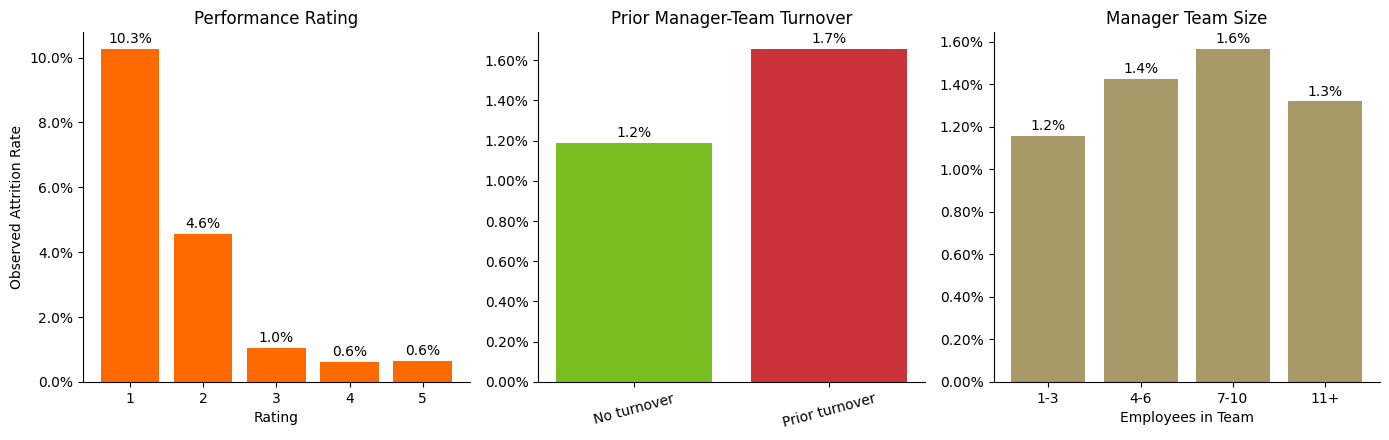

In [12]:
# Summarize three additional candidate-feature patterns in one panel.
performance_summary = (
    df_model.dropna(subset=["performance_rating"])
    .groupby("performance_rating")
    .agg(records=(TARGET_COL, "size"), attrition_rate=(TARGET_COL, "mean"))
    .query("records >= 30")
    .sort_index()
    .reset_index()
)

df_model["manager_turnover_group"] = np.where(
    df_model["mgr_attrition_12mo_rate"].fillna(0) > 0,
    "Prior turnover",
    "No turnover",
)
manager_turnover_summary = (
    df_model.groupby("manager_turnover_group")
    .agg(records=(TARGET_COL, "size"), attrition_rate=(TARGET_COL, "mean"))
    .sort_values("attrition_rate")
    .reset_index()
)

team_size_labels = ["1-3", "4-6", "7-10", "11+"]
df_model["team_size_group"] = pd.cut(
    df_model["mgr_team_size"],
    bins=[0, 4, 7, 11, np.inf],
    labels=team_size_labels,
    right=False,
    include_lowest=True,
)
team_size_summary = (
    df_model.dropna(subset=["team_size_group"])
    .groupby("team_size_group", observed=False)
    .agg(records=(TARGET_COL, "size"), attrition_rate=(TARGET_COL, "mean"))
    .reindex(team_size_labels)
    .reset_index()
)

# Select the team-size group with the highest observed rate for the summary.
highest_team_size = team_size_summary.loc[
    team_size_summary["attrition_rate"].idxmax()
]
key_pattern_summary = pd.DataFrame({
    "pattern": [
        "Performance rating 1",
        "Prior manager-team turnover",
        f"Manager team size {highest_team_size['team_size_group']}",
    ],
    "records": [
        int(performance_summary.loc[performance_summary["performance_rating"] == 1, "records"].iloc[0]),
        int(manager_turnover_summary.loc[manager_turnover_summary["manager_turnover_group"] == "Prior turnover", "records"].iloc[0]),
        int(highest_team_size["records"]),
    ],
    "observed_attrition_rate": [
        performance_summary.loc[performance_summary["performance_rating"] == 1, "attrition_rate"].iloc[0],
        manager_turnover_summary.loc[manager_turnover_summary["manager_turnover_group"] == "Prior turnover", "attrition_rate"].iloc[0],
        highest_team_size["attrition_rate"],
    ],
})
display(key_pattern_summary.style.format({"observed_attrition_rate": "{:.2%}"}))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
performance_bars = axes[0].bar(
    performance_summary["performance_rating"].astype(int).astype(str),
    performance_summary["attrition_rate"],
    color=kp_palette_dict["orange"],
)
axes[0].bar_label(performance_bars, labels=performance_summary["attrition_rate"].map("{:.1%}".format), padding=2)
axes[0].set_title("Performance Rating")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Observed Attrition Rate")

turnover_bars = axes[1].bar(
    manager_turnover_summary["manager_turnover_group"],
    manager_turnover_summary["attrition_rate"],
    color=[kp_palette_dict["green"], kp_palette_dict["red"]],
)
axes[1].bar_label(turnover_bars, labels=manager_turnover_summary["attrition_rate"].map("{:.1%}".format), padding=2)
axes[1].set_title("Prior Manager-Team Turnover")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=15)

team_bars = axes[2].bar(
    team_size_summary["team_size_group"].astype(str),
    team_size_summary["attrition_rate"],
    color=kp_palette_dict["olive_gold"],
)
axes[2].bar_label(team_bars, labels=team_size_summary["attrition_rate"].map("{:.1%}".format), padding=2)
axes[2].set_title("Manager Team Size")
axes[2].set_xlabel("Employees in Team")

axes[0].yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
axes[2].yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
sns.despine()
plt.tight_layout()
plt.show()


Three additional results refine my view of the candidate features:

- Performance rating 1 has an observed attrition rate near 10%, but only about 700 employee-month records have that rating.
- Records with prior manager-team turnover have a rate near 1.7%, compared with about 1.2% when no prior turnover is recorded.
- Team-size rates range from about 1.2% to 1.6%, with the highest rate among teams of 7 to 10 employees. This difference is modest beside the performance and early-tenure patterns.

These groups can differ in job, location, tenure, and other circumstances. I will test their information together rather than interpret one descriptive comparison as a cause or an HR action rule.


## 7. Simple Classification Baseline

The assignment calls for an initial model that can serve as a comparison later. I use Logistic Regression because it is a transparent starting point for a two-outcome question, not because I expect it to be the final model. I train on earlier labeled snapshots, leave six calendar months unused so training and validation outcome windows do not overlap, and evaluate on the latest three fully labeled months. There is no test-set tuning in this EDA notebook.

I use **average precision** as the main metric. It summarizes how well the model ranks true attrition cases near the top across possible review cutoffs. This is more informative than accuracy when only about 1% of employee-month records have a positive outcome. The validation attrition rate is the reference score for a random ranking. This first model uses tenure, the previous year's performance rating, and broad job and organizational groups; it does not search for the best feature set.

In [13]:
# Fit all cleaning steps on earlier training snapshots only.
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

baseline_numeric = [
    "tenure_months", "performance_rating",
]
baseline_categorical = ["region", "entity", "job_family"]
baseline_features = baseline_numeric + baseline_categorical

mature_months = sorted(df_model["snapshot_date"].unique())
validation_months = mature_months[-3:]
validation_start = pd.Timestamp(validation_months[0])
training_end = validation_start - pd.offsets.MonthEnd(7)
train_mask = df_model["snapshot_date"].le(training_end)
validation_mask = df_model["snapshot_date"].isin(validation_months)
assert train_mask.any() and validation_mask.any()
assert training_end + pd.offsets.MonthEnd(6) < validation_start

X_train = df_model.loc[train_mask, baseline_features]
y_train = df_model.loc[train_mask, TARGET_COL].astype(int)
X_validation = df_model.loc[validation_mask, baseline_features]
y_validation = df_model.loc[validation_mask, TARGET_COL].astype(int)

numeric_steps = Pipeline([
    ("replace_missing", SimpleImputer(strategy="median")),
    ("scale", RobustScaler()),
])
categorical_steps = Pipeline([
    ("replace_missing", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore")),
])
preparation = ColumnTransformer([
    ("numeric", numeric_steps, baseline_numeric),
    ("categorical", categorical_steps, baseline_categorical),
])
baseline_model = Pipeline([
    ("prepare", preparation),
    ("classify", LogisticRegression(max_iter=300, class_weight="balanced")),
])
baseline_model.fit(X_train, y_train)

# Average precision measures ranking; no decision threshold is selected here.
validation_scores = baseline_model.predict_proba(X_validation)[:, 1]
validation_ap = average_precision_score(y_validation, validation_scores)
validation_base_rate = y_validation.mean()
baseline_results = pd.DataFrame({
    "validation_records": [len(y_validation)],
    "validation_attrition_rate": [validation_base_rate],
    "average_precision": [validation_ap],
    "lift_over_random": [validation_ap / validation_base_rate],
})
print(
    "Training through:", training_end.date(),
    "| Validation:", validation_start.date(),
    "to", pd.Timestamp(validation_months[-1]).date(),
    "| Training records:", f"{len(y_train):,}",
)
display(baseline_results.style.format({
    "validation_records": "{:,}",
    "validation_attrition_rate": "{:.2%}",
    "average_precision": "{:.2%}",
    "lift_over_random": "{:.1f}x",
}))

Training through: 2025-04-30 | Validation: 2025-11-30 to 2026-01-31 | Training records: 1,817,329


,validation_records,validation_attrition_rate,average_precision,lift_over_random
0,"273,123",1.30%,3.13%,2.4x


The baseline reaches average precision of about **3.1%** on later snapshots, compared with an observed attrition rate of about **1.3%**. That is roughly 2.4 times the reference level for a random ranking. It shows some ability to place future attrition cases nearer the top, but the absolute score remains modest; this is not a ready-to-use HR alert list.

I checked that the employee-month counts and positive cases in all 23 training and validation snapshots match the EDA extract. This first score is a comparison point, not a selected forecast. The separate modeling notebook will test more features and algorithms, choose a practical review cutoff on validation data, and evaluate the final choice on a held-out test period.

## 8. Next Step: Expanded Model Comparison

The EDA shows that six-month voluntary attrition is an uncommon classification outcome and that no single feature clearly identifies who will leave. Short tenure is the clearest numeric pattern. Performance rating 1 and selected job families and departments also have higher observed rates, but those findings need context because some groups are small or specialized.

The source procedure provides complete target values through the January 2026 snapshot. Later snapshots remain in the source for future scoring but are excluded from target-based EDA until their six-month outcomes are fully available.

After this simple baseline, the separate modeling stage will:

1. Split the data by calendar date so each model is evaluated on later, fully mature workforce snapshots.
2. Handle missing values inside the modeling pipeline using training data only.
3. Compare broad categorical features with selected numeric features, then evaluate job family, department, or job code as separate feature-set tests.
4. Retain a categorical field only when improvement holds in later calendar periods and justifies the added complexity.
5. Compare Logistic Regression, Random Forest, and Gradient Boosting using the same validated feature set.
6. Use measures suited to an uncommon outcome, including average precision, recall, precision, lift, and the size of the HR review list.

The final model will provide a relative risk ranking for additional HR review. It will not predict with certainty that an employee will leave, explain why attrition occurs, or justify an individual employment decision.
